In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision.models import resnet18
import os, json
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# SAVE_DIR = "./simclr_checkpoints"
# os.makedirs(SAVE_DIR, exist_ok=True)


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/google_colab/AI_HW2"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# from google.colab import files
# uploaded = files.upload()

Saving best.pth to best.pth


In [ ]:

class SimCLRTransform:
    def __init__(self):
        self.transform = T.Compose([
            T.RandomResizedCrop(32),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.5,0.5,0.5,0.1),
            T.RandomGrayscale(p=0.2),
            T.ToTensor(),
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=SimCLRTransform()
)

train_loader = DataLoader(train_dataset, batch_size=128,
                          shuffle=True, num_workers=2, drop_last=True)

# For kNN (NO augmentation!)
test_transform = T.Compose([T.ToTensor()])
memory_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=test_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=test_transform
)

memory_loader = DataLoader(memory_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


100%|██████████| 170M/170M [00:20<00:00, 8.49MB/s]


In [ ]:
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = resnet18(pretrained=False)

        # CIFAR fix
        self.encoder.conv1 = nn.Conv2d(3,64,3,1,1,bias=False)
        self.encoder.maxpool = nn.Identity()

        dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(dim,512),
            nn.ReLU(),
            nn.Linear(512,128)
        )

    def forward(self,x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

model = SimCLR().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
def nt_xent_loss(z1,z2,temp=0.5):
    N = z1.size(0)
    z = torch.cat([z1,z2],dim=0)

    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temp

    mask = torch.eye(2*N,dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask,-9e15)

    positives = torch.cat([torch.arange(N,2*N), torch.arange(0,N)]).to(device)

    return F.cross_entropy(sim, positives)

In [ ]:
@torch.no_grad()
def knn_monitor(model, memory_loader, test_loader, k=20):
    model.eval()

    # Build feature bank
    feature_bank = []
    label_bank = []

    for data, target in memory_loader:
        data = data.to(device)
        feature = model.encoder(data)
        feature = F.normalize(feature, dim=1)

        feature_bank.append(feature)
        label_bank.append(target)

    feature_bank = torch.cat(feature_bank, dim=0).t()
    label_bank = torch.cat(label_bank).to(device)

    total_top1 = 0
    total_num = 0

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        feature = model.encoder(data)
        feature = F.normalize(feature, dim=1)

        sim_matrix = torch.mm(feature, feature_bank)
        sim_weight, sim_indices = sim_matrix.topk(k=k, dim=-1)

        sim_labels = label_bank[sim_indices]

        pred_scores = torch.zeros(data.size(0), 10).to(device)

        for i in range(k):
            pred_scores.scatter_add_(1, sim_labels[:, i].unsqueeze(-1), sim_weight[:, i].unsqueeze(-1))

        pred_labels = pred_scores.argmax(dim=1)

        total_top1 += (pred_labels == target).sum().item()
        total_num += data.size(0)

    return total_top1 / total_num

In [ ]:
def save_checkpoint(model, optimizer, epoch, best_loss, history, path):
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'opt': optimizer.state_dict(),
        'best_loss': best_loss,
        'history': history
    }, path)

def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['opt'])
    return ckpt

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

history = {"loss": [], "knn": []}
best_loss = float("inf")
start_epoch = 0

RESUME_PATH = None

if RESUME_PATH and os.path.exists(RESUME_PATH):
    ckpt = load_checkpoint(RESUME_PATH)
    start_epoch = ckpt['epoch'] + 1
    best_loss = ckpt['best_loss']
    history = ckpt['history']
    print("Resumed from epoch", start_epoch)

epochs = 100
knn_every = 5

for epoch in range(start_epoch, epochs):
    model.train()
    total_loss = 0

    for (x1,x2), _ in train_loader:
        x1,x2 = x1.to(device), x2.to(device)

        z1 = model(x1)
        z2 = model(x2)

        loss = nt_xent_loss(z1,z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history["loss"].append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # kNN monitor
    if (epoch+1) % knn_every == 0:
        acc = knn_monitor(model, memory_loader, test_loader)
        history["knn"].append(acc)
        print(f"🔍 kNN Accuracy: {acc:.4f}")

    # Save latest
    # save_checkpoint(model, optimizer, epoch, best_loss, history,
    #                 os.path.join(SAVE_DIR,"latest.pth"))

    # Save best
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_checkpoint(model, optimizer, epoch, best_loss, history,
                        os.path.join(SAVE_DIR,"best.pth"))
        print("Saved best model")

# Save history
with open(os.path.join(SAVE_DIR,"history.json"),"w") as f:
    json.dump(history,f)


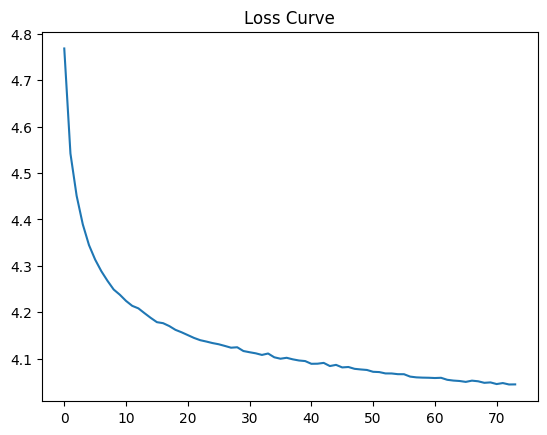

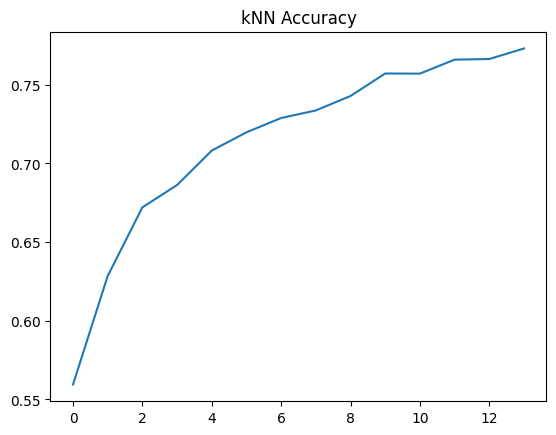

In [ ]:
plt.plot(history["loss"])
plt.title("Loss Curve")
plt.show()

plt.plot(range(len(history["knn"])), history["knn"])
plt.title("kNN Accuracy")
plt.show()

In [ ]:
# Load best trained SimCLR model
ckpt = torch.load("./best.pth", map_location=device)
model.load_state_dict(ckpt['model'])

print("Loaded best SimCLR model")

Loaded best SimCLR model


In [ ]:
# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

# Linear classifier (512 -> 10)
classifier = nn.Linear(512, 10).to(device)

In [ ]:
transform = T.Compose([
    T.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()

epochs = 50

In [ ]:
def evaluate():
    classifier.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            features = model.encoder(x)
            outputs = classifier(features)

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


for epoch in range(epochs):
    classifier.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            features = model.encoder(x)

        outputs = classifier(features)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    acc = evaluate()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")

Epoch 1, Loss: 0.7962, Test Acc: 0.7562
Epoch 2, Loss: 0.6450, Test Acc: 0.7697
Epoch 3, Loss: 0.6214, Test Acc: 0.7753
Epoch 4, Loss: 0.6069, Test Acc: 0.7743
Epoch 5, Loss: 0.5973, Test Acc: 0.7795
Epoch 6, Loss: 0.5870, Test Acc: 0.7811
Epoch 7, Loss: 0.5797, Test Acc: 0.7835
Epoch 8, Loss: 0.5737, Test Acc: 0.7765
Epoch 9, Loss: 0.5691, Test Acc: 0.7850
Epoch 10, Loss: 0.5648, Test Acc: 0.7855
Epoch 11, Loss: 0.5606, Test Acc: 0.7879
Epoch 12, Loss: 0.5568, Test Acc: 0.7926
Epoch 13, Loss: 0.5535, Test Acc: 0.7899
Epoch 14, Loss: 0.5489, Test Acc: 0.7921
Epoch 15, Loss: 0.5466, Test Acc: 0.7936
Epoch 16, Loss: 0.5440, Test Acc: 0.7933
Epoch 17, Loss: 0.5412, Test Acc: 0.7942
Epoch 18, Loss: 0.5376, Test Acc: 0.7975
Epoch 19, Loss: 0.5359, Test Acc: 0.7970
Epoch 20, Loss: 0.5324, Test Acc: 0.7978
Epoch 21, Loss: 0.5319, Test Acc: 0.7972
Epoch 22, Loss: 0.5298, Test Acc: 0.7977
Epoch 23, Loss: 0.5278, Test Acc: 0.7967
Epoch 24, Loss: 0.5267, Test Acc: 0.7996
Epoch 25, Loss: 0.5259, T

# Supervised Baseline

In [ ]:
transform_train = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

transform_test = T.Compose([
    T.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
class ResNet18_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = resnet18(pretrained=False)

        # SAME CIFAR FIX
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

        # classifier head
        self.model.fc = nn.Linear(512, 10)

    def forward(self, x):
        return self.model(x)

model_sl = ResNet18_CIFAR().to(device)

In [ ]:
optimizer = torch.optim.Adam(model_sl.parameters(), lr=1e-3, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()

epochs = 70

In [ ]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
best_acc = 0

for epoch in range(epochs):
    model_sl.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        outputs = model_sl(x)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    acc = evaluate(model_sl)

    if acc > best_acc:
        best_acc = acc

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")

print("Best Supervised Accuracy:", best_acc)

Epoch 1, Loss: 1.2126, Test Acc: 0.6509
Epoch 2, Loss: 0.7245, Test Acc: 0.7481
Epoch 3, Loss: 0.5485, Test Acc: 0.7928
Epoch 4, Loss: 0.4537, Test Acc: 0.7609
Epoch 5, Loss: 0.3794, Test Acc: 0.7897
Epoch 6, Loss: 0.3190, Test Acc: 0.8399
Epoch 7, Loss: 0.2773, Test Acc: 0.8493
Epoch 8, Loss: 0.2294, Test Acc: 0.8301
Epoch 9, Loss: 0.1916, Test Acc: 0.8426
Epoch 10, Loss: 0.1653, Test Acc: 0.8497
Epoch 11, Loss: 0.1378, Test Acc: 0.8612
Epoch 12, Loss: 0.1210, Test Acc: 0.8502
Epoch 13, Loss: 0.1063, Test Acc: 0.8559
Epoch 14, Loss: 0.0955, Test Acc: 0.8658
Epoch 15, Loss: 0.0861, Test Acc: 0.8568
Epoch 16, Loss: 0.0785, Test Acc: 0.8604
Epoch 17, Loss: 0.0680, Test Acc: 0.8550
Epoch 18, Loss: 0.0662, Test Acc: 0.8609
Epoch 19, Loss: 0.0569, Test Acc: 0.8683
Epoch 20, Loss: 0.0517, Test Acc: 0.8696
Epoch 21, Loss: 0.0551, Test Acc: 0.8663
Epoch 22, Loss: 0.0535, Test Acc: 0.8771
Epoch 23, Loss: 0.0380, Test Acc: 0.8785
Epoch 24, Loss: 0.0445, Test Acc: 0.8637
Epoch 25, Loss: 0.0453, T